`multimodal (text + tables + images) RAG` = https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb?ref=blog.langchain.dev

`Semi_structured_multi_modal_RAG_LLaMA2` = https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_multi_modal_RAG_LLaMA2.ipynb

In [1]:
# %pip install -Uq "unstructured[all-docs]" pillow lxml pillow
# %pip install -Uq chromadb tiktoken
# %pip install -Uq langchain langchain-community langchain-openai langchain-groq
# %pip install -Uq python_dotenv

In [2]:
import pandas as pd

In [3]:
import os
from typing import Any
from pydantic import BaseModel
from unstructured.partition.pdf import partition_pdf

In [4]:
# Setup paths
img_dir = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\figures"
file_path = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\data\Audit Report Hulas Infra 208081_250514_120336.pdf"
# file_path1 = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\data\IAC_2020-Balance-Sheet-Example.pdf"
poppler_path = r"C:\poppler-24.08.0\Library\bin"
tesseract_dir = r"C:\Users\ganes_3ck5\AppData\Local\Programs\Tesseract-OCR"
tesseract_exe = os.path.join(tesseract_dir, "tesseract.exe")

In [5]:
# Set environment variables
os.environ["PATH"] = f"{poppler_path}{os.pathsep}{tesseract_dir}{os.pathsep}{os.environ['PATH']}"
os.environ["POPPLER_PATH"] = poppler_path
os.environ["TESSDATA_PREFIX"] = os.path.join(tesseract_dir, "tessdata")
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'

### Partition PDF tables, text, and images
Read a PDF, extract structured content (text, images, tables), split it into chunks, save images, and use OCR if needed.

In [6]:
# ## without chunking
# raw_pdf_elements = partition_pdf(
#     filename=file_path1,
#     # extract_images_in_pdf=True, # Extracts actual images from the PDF (e.g., logos, charts, scanned pages)
#     # image_output_dir_path=img_dir,
#     extract_image_block_types = ["Image"], # extracts image i.e is type = image
#     extract_image_block_to_payload=True,   # if true, will extract base64 for API usage
#     infer_table_structure=True, #  Detects and reconstructs table layouts in the PDF using a layout model (like YOLOX)
#     # chunking_strategy="by_title", # Organizes and groups content into "chunks" or sections based on document titles/headings
#     # max_characters=4000, # Specifies the maximum number of characters per chunk.
#     # new_after_n_chars=3800, #  Tries to create a new chunk after approximately 3800 characters, even if the hard max is 4000
#     # combine_text_under_n_chars=2000, # Combines chunks that are smaller than 2000 characters with adjacent ones
#     poppler_path=poppler_path, #  Path to the Poppler utilities, which are required to convert PDF pages into images.
#     languages=["eng"],  # For English text
#     strategy="hi_res",    # OCR processing strategy that uses high-resolution image conversion for better accuracy.
#     tesseract_path=tesseract_exe  # Full path to the Tesseract OCR executable
# )
# print(f"Successfully processed {len(raw_pdf_elements)} elements")
# print(f"Images saved to: {img_dir}")

# set([str(type(el)) for el in raw_pdf_elements])

In [7]:
# raw_pdf_elements[3].metadata.orig_elements

In [8]:
raw_pdf_elements = partition_pdf(
    filename=file_path,
    # extract_images_in_pdf=True, # Extracts actual images from the PDF (e.g., logos, charts, scanned pages)
    # image_output_dir_path=img_dir,
    extract_image_block_types = ["Image", "Table"], # extracts image i.e is type = image
    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage
    infer_table_structure=True, #  Detects and reconstructs table layouts in the PDF using a layout model (like YOLOX)
    chunking_strategy="by_title", # Organizes and groups content into "chunks" or sections based on document titles/headings
    max_characters=4000, # Specifies the maximum number of characters per chunk.
    new_after_n_chars=3800, #  Tries to create a new chunk after approximately 3800 characters, even if the hard max is 4000
    combine_text_under_n_chars=2000, # Combines chunks that are smaller than 2000 characters with adjacent ones
    poppler_path=poppler_path, #  Path to the Poppler utilities, which are required to convert PDF pages into images.
    languages=["eng"],  # For English text
    strategy="hi_res",    # OCR processing strategy that uses high-resolution image conversion for better accuracy.
    tesseract_path=tesseract_exe  # Full path to the Tesseract OCR executable
)
print(f"Successfully processed {len(raw_pdf_elements)} elements")
print(f"Images saved to: {img_dir}")

# We get single types of elements from the partition_pdf function i.e CompositeElement
set([str(type(el)) for el in raw_pdf_elements])

Successfully processed 27 elements
Images saved to: C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\figures


{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [9]:
len(raw_pdf_elements)

27

In [10]:
from collections import Counter
from unstructured.documents.elements import CompositeElement, Table

type_counts = Counter(type(el) for el in raw_pdf_elements)
print(type_counts)

# Check tables inside CompositeElements using metadata.orig_elements
for el in raw_pdf_elements:
    if isinstance(el, CompositeElement):
        if hasattr(el.metadata, "orig_elements") and el.metadata.orig_elements:
            tables_inside = [e for e in el.metadata.orig_elements if isinstance(e, Table)]
            print(f"CompositeElement with {len(tables_inside)} tables inside.")


Counter({<class 'unstructured.documents.elements.CompositeElement'>: 27})
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 1 tables inside.
CompositeElement with 1 tables inside.
CompositeElement with 1 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 1 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 1 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 0 tables inside.
CompositeElement with 2 tables inside.
CompositeElement with 5 tables inside.
CompositeElement with 2 tables inside.
CompositeElement with 6 tables inside.
CompositeElement with 5 tables inside.
CompositeElement with 0 table

In [ ]:
unique_types = set()

for el in raw_pdf_elements:
    if hasattr(el, 'metadata'):
        meta = el.metadata.to_dict()
        if 'orig_elements' in meta:
            for orig_el in meta['orig_elements']:
                unique_types.add(type(orig_el).__name__)

print("Unique content types found in the PDF:")
for t in sorted(unique_types):
    print(t)

In [11]:
from unstructured.documents.elements import Table

tables = []
for el in raw_pdf_elements:
    if hasattr(el.metadata, "orig_elements"):
        tables += [e for e in el.metadata.orig_elements if isinstance(e, Table)]

print(f"Total tables extracted: {len(tables)}")

for idx, table in enumerate(tables):
    print(f"\n--- Table {idx+1} ---")
    print(table.to_dict())

Total tables extracted: 30

--- Table 1 ---
{'type': 'Table', 'element_id': '7a48f069-7dea-472e-9fd4-9be266eb3f57', 'text': 'oo Sates (Ahad 31, 2081) (haha A 2080) Assets Non Current Assets Property, Plant & Equipment 4 2,394,895,500 1,783,114,137 Intangible Assets 5 2,532,176 3,063,882 Deferred Tax Assets 6 Total Non Current Assets 2,397 ,427,676 1,786,178,019 Current Assets Inventories 7 1,072,781,746 530,101,113 Financial Assets Trade Receivables 8 785,398,356 173,794,446 Cash & Cash Equivalent 9 19,045,197 6,253,038 Others 10 32,349,193 29,403,348 Other Current Assets 11 365,808,157 482,375,730 Income Tax Assets (Net) 20 10,036,192 1,294,630 Total Current Assets 2,285,418,841 1,223,222,304 Total Assets 4,682,846,517 3,009,400,323 Bach Equity & Liabilities Equity Equity Share Capital 12 (a) 500,000,000 500,000,000 Other Equi 12 333,899,354 177,230,837 Total Equity 833,899,354 677,230,837 Non Current Liabilities Financial Liabilities Long Term Borrowings 13 1,485,799,954 1,216,444,22

In [12]:
# Counts how many elements of each type (e.g., Text, Title, TableChunk) were extracted from the PDF and store it in category_counts
category_counts = {}

for element in raw_pdf_elements:
    category = str(type(element))
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# Unique_categories will have unique elements
# TableChunk if Table > max chars set above
unique_categories = set(category_counts.keys())
category_counts

{"<class 'unstructured.documents.elements.CompositeElement'>": 27}

In [13]:
raw_pdf_elements[0].to_dict()

{'type': 'CompositeElement',
 'element_id': 'cff489de0dda72ccb442ad4b6acec123',
 'text': "S UBHASH & Co.\n\nChartered Accountants House No. 199 Tanka Prasad Marg Old Baneshwor Height Kathmandu, Nepal\n\n_Tel.: 01-4597223, 4582239 P.O. Box: 129, Kathmandu E-mail: info@snco.com.np\n\nINDEPENDENT AUDITOR'S REPORT\n\nTO THE SHAREHOLDERS OF HULAS INFRA LTD.(Previously Hulas Infra Pvt. Ltd.)\n\nOpini\n\nWe have audited the accompanying Financial Statements of Hulas Infra Ltd.(Previously Hulas Infra Pvt. Ltd.) which comprises the Statement of Financial Position as at Ashad 31, 2081, Statement of Profit or Loss & Other Comprehensive Income, Statement of Changes in Equity & Statement of Cash Flows for the year ended Ashad 31, 2081, and Notes to Financial Statement including Summary of Significant Accounting Policies.\n\n“In\n\nour opinion and to the best of our information and according to the explanations given to us, the aforesaid Financial Statements give a true and fair view in conformity w

In [14]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

raw_pdf_elements[0].metadata.orig_elements

In [15]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = raw_pdf_elements[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
if chunk_images:
    print(chunk_images[0].to_dict())
else:
    print("No images found in this chunk.")

{'type': 'Image', 'element_id': '1c7a980a-0590-4be8-87b5-76a2e5c0b028', 'text': 'Place: Kathmandu Date: 2024-12-11', 'metadata': {'detection_class_prob': 0.4712335467338562, 'coordinates': {'points': ((np.float64(81.62777709960938), np.float64(1843.1553955078125)), (np.float64(81.62777709960938), np.float64(2188.934326171875)), (np.float64(516.5770874023438), np.float64(2188.934326171875)), (np.float64(516.5770874023438), np.float64(1843.1553955078125))), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2025-05-14T12:54:12', 'filetype': 'PPM', 'languages': ['eng'], 'page_number': 2, 'image_base64': '...', 'image_mime_type': 'image/jpeg'}}


In [16]:
for idx, tbl in enumerate(chunk_images):
    print(f"\n--- Image {idx+1} ---")
    print(tbl.to_dict())


--- Image 1 ---
{'type': 'Image', 'element_id': '1c7a980a-0590-4be8-87b5-76a2e5c0b028', 'text': 'Place: Kathmandu Date: 2024-12-11', 'metadata': {'detection_class_prob': 0.4712335467338562, 'coordinates': {'points': ((np.float64(81.62777709960938), np.float64(1843.1553955078125)), (np.float64(81.62777709960938), np.float64(2188.934326171875)), (np.float64(516.5770874023438), np.float64(2188.934326171875)), (np.float64(516.5770874023438), np.float64(1843.1553955078125))), 'system': 'PixelSpace', 'layout_width': 1700, 'layout_height': 2200}, 'last_modified': '2025-05-14T12:54:12', 'filetype': 'PPM', 'languages': ['eng'], 'page_number': 2, 'image_base64': '...', 'image_mime_type': 'image/jpeg'}}

--- Image 2 ---
{'type': 'Image', 'element_id': 'c648c6e4-0caa-4a0e-9401-90cfa7cfda20', 'text': '', 'metadata': {'detection_class_prob': 0.3330134451389313, 'coordinates': {'points': ((np.float64(584.2830810546875), np.float64(1949.7845458984375)), (np.float64(584.2830810546875), np.float64(2073

In [17]:
raw_pdf_elements[1].to_dict()

{'type': 'CompositeElement',
 'element_id': 'd4a6052bb8d464e7ce8aa0ac57edf381',
 'text': "Managements for the Financial Statements\n\nResponsibility\n\nManagement is responsible for preparation and fair presentation of the Financial Statements in accordance with the Nepal Financial Reporting Standards (NFRSs) and for such internal control as management determines is necessary to enable the preparation of Financial Statements that are free from material misstatement, whether due to fraud or error.\n\nIn preparing the Financial Statements, management is responsible for assessing its ability to continue as a going concern, disclosing, as applicable, matters related to going concern and using the going concern basis of accounting unless the management either intends to liqtiidate or cease operations, or has no realistic alternative but to do so.\n\nThose charged with governance are responsible for overseeing the Company’s Financial Reporting process.\n\nAuditor's R ibility for the Audit of

In [18]:
raw_pdf_elements[3].metadata.orig_elements

In [19]:
# This is what an extracted table looks like.

elements = raw_pdf_elements[3].metadata.orig_elements
chunk_table = [el for el in elements if 'Table' in str(type(el))]
if chunk_table:
    print(chunk_table[0].to_dict())
else:
    print("No table found in this chunk.")

{'type': 'Table', 'element_id': '7a48f069-7dea-472e-9fd4-9be266eb3f57', 'text': 'oo Sates (Ahad 31, 2081) (haha A 2080) Assets Non Current Assets Property, Plant & Equipment 4 2,394,895,500 1,783,114,137 Intangible Assets 5 2,532,176 3,063,882 Deferred Tax Assets 6 Total Non Current Assets 2,397 ,427,676 1,786,178,019 Current Assets Inventories 7 1,072,781,746 530,101,113 Financial Assets Trade Receivables 8 785,398,356 173,794,446 Cash & Cash Equivalent 9 19,045,197 6,253,038 Others 10 32,349,193 29,403,348 Other Current Assets 11 365,808,157 482,375,730 Income Tax Assets (Net) 20 10,036,192 1,294,630 Total Current Assets 2,285,418,841 1,223,222,304 Total Assets 4,682,846,517 3,009,400,323 Bach Equity & Liabilities Equity Equity Share Capital 12 (a) 500,000,000 500,000,000 Other Equi 12 333,899,354 177,230,837 Total Equity 833,899,354 677,230,837 Non Current Liabilities Financial Liabilities Long Term Borrowings 13 1,485,799,954 1,216,444,222 Other Financial Liabilities 14 393,880,356

In [20]:
for idx, tbl in enumerate(chunk_table):
    print(f"\n--- Table {idx+1} ---")
    print(tbl.to_dict())


--- Table 1 ---
{'type': 'Table', 'element_id': '7a48f069-7dea-472e-9fd4-9be266eb3f57', 'text': 'oo Sates (Ahad 31, 2081) (haha A 2080) Assets Non Current Assets Property, Plant & Equipment 4 2,394,895,500 1,783,114,137 Intangible Assets 5 2,532,176 3,063,882 Deferred Tax Assets 6 Total Non Current Assets 2,397 ,427,676 1,786,178,019 Current Assets Inventories 7 1,072,781,746 530,101,113 Financial Assets Trade Receivables 8 785,398,356 173,794,446 Cash & Cash Equivalent 9 19,045,197 6,253,038 Others 10 32,349,193 29,403,348 Other Current Assets 11 365,808,157 482,375,730 Income Tax Assets (Net) 20 10,036,192 1,294,630 Total Current Assets 2,285,418,841 1,223,222,304 Total Assets 4,682,846,517 3,009,400,323 Bach Equity & Liabilities Equity Equity Share Capital 12 (a) 500,000,000 500,000,000 Other Equi 12 333,899,354 177,230,837 Total Equity 833,899,354 677,230,837 Non Current Liabilities Financial Liabilities Long Term Borrowings 13 1,485,799,954 1,216,444,222 Other Financial Liabiliti

In [21]:
table_dict = chunk_table[0].to_dict()
tables_html = [table.metadata.text_as_html for table in chunk_table]

tables_html

['<table><thead></thead><tbody><tr><td rowspan="6">As sets Non Current Assets Property, Plant &amp; Equipment Intangible Assets Deferred Tax Assets Total Non Current Assets</td><td rowspan="5">4 5 6</td><td rowspan="5">(Ashad 31, 2081) 2,394,895,500 2,532,176</td><td rowspan="6">(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786,178,019</td></tr><tr><td></td><td>2,397 ,427,676</td></tr><tr><td colspan="4">Current Assets</td></tr><tr><td colspan="4">Inventories 7 1,072,781,746</td></tr><tr><td colspan="4">530,101,113 Financial Assets</td></tr><tr><td>Trade Receivables</td><td>8</td><td></td><td></td></tr><tr><td>Cash &amp; Cash Equivalent</td><td>9</td><td>785,398,356</td><td>173,794,446</td></tr><tr><td>Others</td><td>10</td><td>19,045,197</td><td>6,253,038</td></tr><tr><td></td><td></td><td>32,349,193</td><td>29,403,348</td></tr><tr><td>Other Current Assets</td><td>11</td><td>365,808,157</td><td>482,375,730</td></tr><tr><td>Income Tax Assets</td><td></td><td></td><td></td></tr><tr><td>(Ne

In [22]:
# turn the table into a usable format like a DataFrame
import pandas as pd

table_dict = chunk_table[0].to_dict()
html = table_dict['metadata']['text_as_html']

html

'<table><thead></thead><tbody><tr><td rowspan="6">As sets Non Current Assets Property, Plant &amp; Equipment Intangible Assets Deferred Tax Assets Total Non Current Assets</td><td rowspan="5">4 5 6</td><td rowspan="5">(Ashad 31, 2081) 2,394,895,500 2,532,176</td><td rowspan="6">(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786,178,019</td></tr><tr><td></td><td>2,397 ,427,676</td></tr><tr><td colspan="4">Current Assets</td></tr><tr><td colspan="4">Inventories 7 1,072,781,746</td></tr><tr><td colspan="4">530,101,113 Financial Assets</td></tr><tr><td>Trade Receivables</td><td>8</td><td></td><td></td></tr><tr><td>Cash &amp; Cash Equivalent</td><td>9</td><td>785,398,356</td><td>173,794,446</td></tr><tr><td>Others</td><td>10</td><td>19,045,197</td><td>6,253,038</td></tr><tr><td></td><td></td><td>32,349,193</td><td>29,403,348</td></tr><tr><td>Other Current Assets</td><td>11</td><td>365,808,157</td><td>482,375,730</td></tr><tr><td>Income Tax Assets</td><td></td><td></td><td></td></tr><tr><td>(Net

In [23]:
df = pd.read_html(html)[0]
df.head()

C:\Users\ganes_3ck5\AppData\Local\Temp\ipykernel_10464\2327705891.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[0]


,0,1,2,3,4,5,6,7
0,"As sets Non Current Assets Property, Plant & E...",4 5 6,"(Ashad 31, 2081) 2,394,895,500 2,532,176","(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786...",NaN,NaN,NaN,NaN
1,"As sets Non Current Assets Property, Plant & E...",4 5 6,"(Ashad 31, 2081) 2,394,895,500 2,532,176","(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786...",NaN,"2,397 ,427,676",NaN,NaN
2,"As sets Non Current Assets Property, Plant & E...",4 5 6,"(Ashad 31, 2081) 2,394,895,500 2,532,176","(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786...",Current Assets,Current Assets,Current Assets,Current Assets
3,"As sets Non Current Assets Property, Plant & E...",4 5 6,"(Ashad 31, 2081) 2,394,895,500 2,532,176","(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786...","Inventories 7 1,072,781,746","Inventories 7 1,072,781,746","Inventories 7 1,072,781,746","Inventories 7 1,072,781,746"
4,"As sets Non Current Assets Property, Plant & E...",4 5 6,"(Ashad 31, 2081) 2,394,895,500 2,532,176","(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786...","530,101,113 Financial Assets","530,101,113 Financial Assets","530,101,113 Financial Assets","530,101,113 Financial Assets"


In [24]:
class Element(BaseModel):
    type: str
    text: Any


# Categorize by type
categorized_elements = []
for element in raw_pdf_elements:
    if "unstructured.documents.elements.Table" in str(type(element)):
        categorized_elements.append(Element(type="table", text=str(element)))
    elif "unstructured.documents.elements.CompositeElement" in str(type(element)):
        categorized_elements.append(Element(type="text", text=str(element)))

In [25]:
categorized_elements[:5]

[Element(type='text', text="S UBHASH & Co.\n\nChartered Accountants House No. 199 Tanka Prasad Marg Old Baneshwor Height Kathmandu, Nepal\n\n_Tel.: 01-4597223, 4582239 P.O. Box: 129, Kathmandu E-mail: info@snco.com.np\n\nINDEPENDENT AUDITOR'S REPORT\n\nTO THE SHAREHOLDERS OF HULAS INFRA LTD.(Previously Hulas Infra Pvt. Ltd.)\n\nOpini\n\nWe have audited the accompanying Financial Statements of Hulas Infra Ltd.(Previously Hulas Infra Pvt. Ltd.) which comprises the Statement of Financial Position as at Ashad 31, 2081, Statement of Profit or Loss & Other Comprehensive Income, Statement of Changes in Equity & Statement of Cash Flows for the year ended Ashad 31, 2081, and Notes to Financial Statement including Summary of Significant Accounting Policies.\n\n“In\n\nour opinion and to the best of our information and according to the explanations given to us, the aforesaid Financial Statements give a true and fair view in conformity with Nepal Financial Reporting Standards (NFRSs), of the state 

In [26]:
types_in_elements = set(el.type for el in categorized_elements)
print(types_in_elements)

{'text'}


## Text => text_elements

In [27]:
# Text
text_elements = [e for e in categorized_elements if e.type == "text"]
print(len(text_elements))

27


In [28]:
text_elements

[Element(type='text', text="S UBHASH & Co.\n\nChartered Accountants House No. 199 Tanka Prasad Marg Old Baneshwor Height Kathmandu, Nepal\n\n_Tel.: 01-4597223, 4582239 P.O. Box: 129, Kathmandu E-mail: info@snco.com.np\n\nINDEPENDENT AUDITOR'S REPORT\n\nTO THE SHAREHOLDERS OF HULAS INFRA LTD.(Previously Hulas Infra Pvt. Ltd.)\n\nOpini\n\nWe have audited the accompanying Financial Statements of Hulas Infra Ltd.(Previously Hulas Infra Pvt. Ltd.) which comprises the Statement of Financial Position as at Ashad 31, 2081, Statement of Profit or Loss & Other Comprehensive Income, Statement of Changes in Equity & Statement of Cash Flows for the year ended Ashad 31, 2081, and Notes to Financial Statement including Summary of Significant Accounting Policies.\n\n“In\n\nour opinion and to the best of our information and according to the explanations given to us, the aforesaid Financial Statements give a true and fair view in conformity with Nepal Financial Reporting Standards (NFRSs), of the state 

## Table => table_elements

In [29]:
# Get the images from the CompositeElement objects
def get_table_elements(raw_pdf_elements):
    table_elements = []
    for chunk in raw_pdf_elements:
        if "unstructured.documents.elements.CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Table" in str(type(el)):
                    table_elements.append(el)  # append the full object
    return table_elements

table_elements = get_table_elements(raw_pdf_elements)

In [30]:
print(f"Total Table Elements: {len(table_elements)}")

Total Table Elements: 30


In [31]:
# Get the images_table from the CompositeElement objects
images_table = [el.metadata.image_base64 for el in table_elements]
images_table

['...']

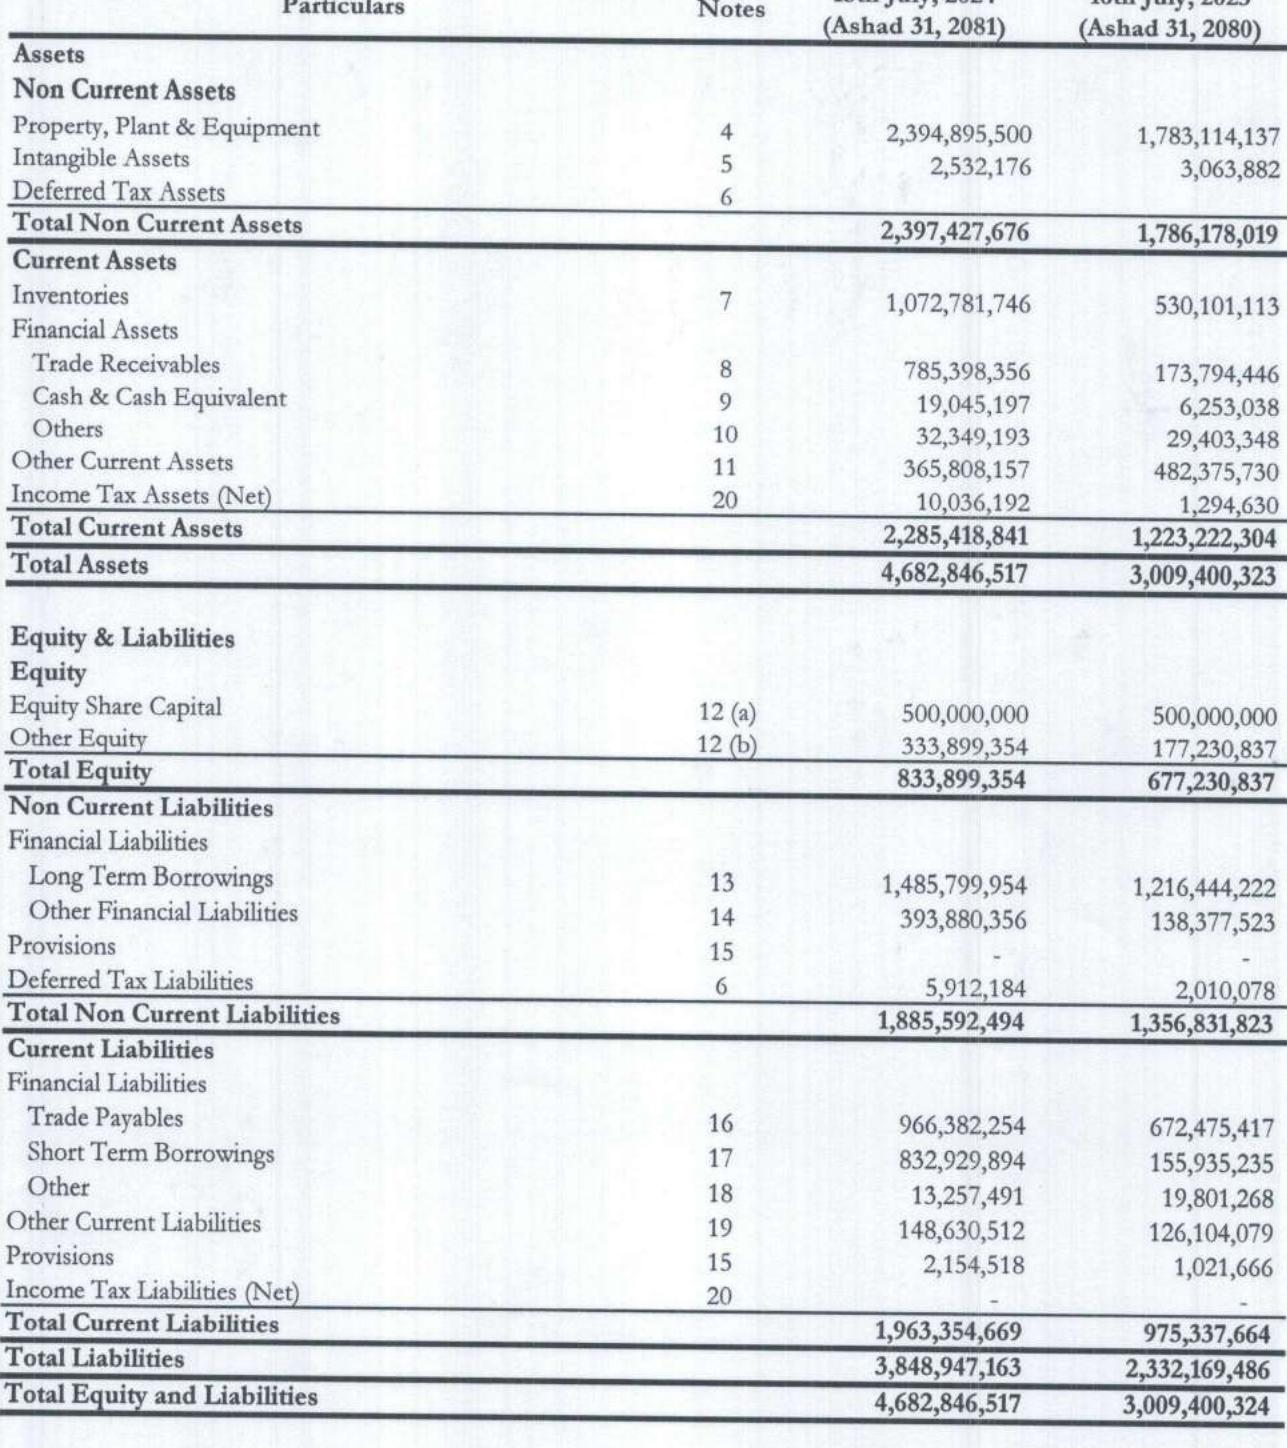

In [32]:
# Check what the images look like
import base64
from IPython.display import Image, display

def display_base64_image_table(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image_table(images_table[0])

In [33]:
# Get the html_table from the CompositeElement objects
html_table = [el.metadata.text_as_html for el in table_elements]
html_table

['<table><thead></thead><tbody><tr><td rowspan="6">As sets Non Current Assets Property, Plant &amp; Equipment Intangible Assets Deferred Tax Assets Total Non Current Assets</td><td rowspan="5">4 5 6</td><td rowspan="5">(Ashad 31, 2081) 2,394,895,500 2,532,176</td><td rowspan="6">(Ashad 31, 2080) 1,783,114,137 3,063,882 1,786,178,019</td></tr><tr><td></td><td>2,397 ,427,676</td></tr><tr><td colspan="4">Current Assets</td></tr><tr><td colspan="4">Inventories 7 1,072,781,746</td></tr><tr><td colspan="4">530,101,113 Financial Assets</td></tr><tr><td>Trade Receivables</td><td>8</td><td></td><td></td></tr><tr><td>Cash &amp; Cash Equivalent</td><td>9</td><td>785,398,356</td><td>173,794,446</td></tr><tr><td>Others</td><td>10</td><td>19,045,197</td><td>6,253,038</td></tr><tr><td></td><td></td><td>32,349,193</td><td>29,403,348</td></tr><tr><td>Other Current Assets</td><td>11</td><td>365,808,157</td><td>482,375,730</td></tr><tr><td>Income Tax Assets</td><td></td><td></td><td></td></tr><tr><td>(Ne

## Images => image_elements

In [34]:
# Get the images from the CompositeElement objects
def get_image_elements(raw_pdf_elements):
    image_elements = []
    for chunk in raw_pdf_elements:
        if "unstructured.documents.elements.CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    image_elements.append(el)  # append the full object
    return image_elements

image_elements = get_image_elements(raw_pdf_elements)

In [35]:
print(f"Total image elements: {len(image_elements)}")

Total image elements: 24


In [36]:
# Get the images_base64 from the CompositeElement objects
images = [el.metadata.image_base64 for el in image_elements]
images

['...']

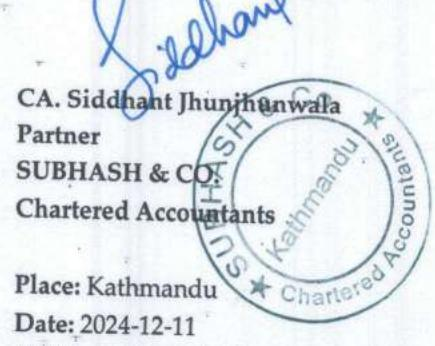

In [37]:
# Check what the images look like
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

In [38]:
sd;lkja;sdajs;dlf;

NameError: name 'sd' is not defined

## Text and Table summaries

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
# Prompt
prompt_text = prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatOllama(model="llama3.2:latest")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [ ]:
# Apply to text
texts = [i.text for i in text_elements if i.text != ""]
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 5})

In [ ]:
# # Save the summarized content
# with open("Audit_Report_Hulas_Infra_208081_250514_120336/balance_sheet_text_summaries.txt", "w", encoding="utf-8") as f:
#     for summary in text_summaries:
#         f.write(summary.strip() + "\n\n")  # Add spacing between summaries

with open("Audit_Report_Hulas_Infra_208081_250514_120336/balance_sheet_text_summaries.txt", "r", encoding="utf-8") as f:
    text_summaries = f.read()

text_summaries

"SUBHASH & Co. Chartered Accountants\nHouse No. 199, Tanka Prasad Marg, Old Baneshwor,\nKathmandu, Nepal, \nPhone: 01-4597223, 4582239, P.O. Box: 129, Kathmandu\nEmail: info@snco.com.np\n\nIndependent Auditor's Report for Hulas Infra Ltd.\nFinancial Statements audited in conformity with Nepal Financial Reporting Standards (NFRSs),\ngiving a true and fair view of the company's state as at Ashad 31, 2081.\n\nManagement prepares and presents financial statements in accordance with Nepal Financial Reporting Standards (NFRSs), ensuring they are free from material misstatement due to fraud or error. Those charged with governance oversee the financial reporting process, while auditors provide reasonable assurance about the accuracy of financial statements through professional judgment and audit procedures.\n\nAudit procedures include evaluating internal control, accounting policies, estimates, and disclosures; assessing going concern basis and material uncertainty; presenting financial statem

In [ ]:
texts

In [ ]:
text_elements

In [ ]:
print(text_elements[0])

In [ ]:
# Apply to tables
tables_html = [table.metadata.text_as_html for table in table_elements if table.metadata.text_as_html]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 5})

In [ ]:
# # Save the summarized content
# with open("Audit_Report_Hulas_Infra_208081_250514_120336/balance_sheet_table_summaries.txt", "w", encoding="utf-8") as f:
#     for summary in table_summaries:
#         f.write(summary.strip() + "\n\n")  # Add spacing between summaries


with open("Audit_Report_Hulas_Infra_208081_250514_120336balance_sheet_text_summaries.txt", "r", encoding="utf-8") as f:
    table_summaries = f.read()


table_summaries

"SUBHASH & Co. Chartered Accountants\nHouse No. 199, Tanka Prasad Marg, Old Baneshwor,\nKathmandu, Nepal, \nPhone: 01-4597223, 4582239, P.O. Box: 129, Kathmandu\nEmail: info@snco.com.np\n\nIndependent Auditor's Report for Hulas Infra Ltd.\nFinancial Statements audited in conformity with Nepal Financial Reporting Standards (NFRSs),\ngiving a true and fair view of the company's state as at Ashad 31, 2081.\n\nManagement prepares and presents financial statements in accordance with Nepal Financial Reporting Standards (NFRSs), ensuring they are free from material misstatement due to fraud or error. Those charged with governance oversee the financial reporting process, while auditors provide reasonable assurance about the accuracy of financial statements through professional judgment and audit procedures.\n\nAudit procedures include evaluating internal control, accounting policies, estimates, and disclosures; assessing going concern basis and material uncertainty; presenting financial statem

In [ ]:
tables_html

In [ ]:
table_elements

In [ ]:
table_summaries

## Image summaries
image summarizaton using LLaVA (Large Language and Vision Assistant) 

In [ ]:
# MODEL_DIR="/c/Users/ganes_3ck5/.cache/huggingface/hub/llama_cpp/"
# # IMG_DIR="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/figures/"
# # LLAVA_EXE="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/llama.cpp/build/bin/Release/llama-llava-cli.exe"
# LLAVA_EXE="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/llama.cpp/build/bin/Release/llama-mtmd-cli.exe"
# TEMP_DIR = "/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/data/temp_images"

In [ ]:
import base64
import os
import glob
import subprocess
import uuid
import json

# === CONFIGURATION ===
MODEL_DIR = r"C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp"
LLAVA_EXE = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\llama.cpp\build\bin\Release\llama-mtmd-cli.exe"

IMG_SUMMARY_DIR="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/Audit_Report_Hulas_Infra_208081_250514_120336"
IMG_DIR="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/Audit_Report_Hulas_Infra_208081_250514_120336"

os.makedirs(IMG_DIR, exist_ok=True)

prompt_template = """You are an image summarizer specialized in financial documents. Analyze the image carefully and describe it in detail. The image is part of a financial report (such as a balance sheet, income statement, cash flow statement, or equity report).

If the image contains:
- Financial tables or charts: Summarize the type of data presented, major figures, trends, or categories.
- Text sections: Transcribe or summarize the content briefly.
- Logos, stamps, signatures, or seals: Identify and describe them, including their placement and potential meaning (e.g., approval, verification, branding).
- Other graphical elements: Explain their relevance in the context of the financial report.

Be clear, concise, and context-aware. Highlight anything unusual, informative, or visually important.
"""

def summarize_base64_image(base64_image: str, image_id: str):
    # Decode and save image temporarily
    image_data = base64.b64decode(base64_image)
    image_path = os.path.join(IMG_DIR, f"{image_id}.jpg")  # e.g. "image_1.jpg"
    with open(image_path, "wb") as f:
        f.write(image_data)

    # Build command for LLava CLI
    command = [
    LLAVA_EXE,
    "-m", os.path.join(MODEL_DIR, "ggml-model-q5_k.gguf"),
    "--mmproj", os.path.join(MODEL_DIR, "mmproj-model-f16.gguf"),
    "--chat-template", "vicuna",
    "--temp", "0.1",
    "-p", prompt_template,
    "--image", image_path
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        output_text = result.stdout
    except subprocess.CalledProcessError as e:
        output_text = f"Error running LLava: {e.stderr}"

    return output_text, image_path

In [ ]:
# Get the images_base64 from the CompositeElement objects
image_elements = get_image_elements(raw_pdf_elements)
images = [el.metadata.image_base64 for el in image_elements]
images[0]

'...'

In [ ]:
img_data = base64.b64decode(images[0])
img_data

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x01Z\x01\xb3\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4

In [ ]:
image_summaries = {}

for i, img in enumerate(images):
    image_id = f"image_{i+1}"
    print(f"Processing {image_id}...")
    summary, img_path = summarize_base64_image(img, image_id)
    image_summaries[image_id] = {
        "summary": summary,
        "image_path": img_path
    }

with open(os.path.join(IMG_SUMMARY_DIR, "image_summaries.json"), "w", encoding="utf-8") as f:
    json.dump(image_summaries, f, indent=2, ensure_ascii=False)

Processing image_1...
Processing image_2...
Processing image_3...
Processing image_4...
Processing image_5...
Processing image_6...
Processing image_7...
Processing image_8...
Processing image_9...
Processing image_10...
Processing image_11...
Processing image_12...
Processing image_13...
Processing image_14...
Processing image_15...
Processing image_16...
Processing image_17...
Processing image_18...
Processing image_19...
Processing image_20...
Processing image_21...
Processing image_22...
Processing image_23...
Processing image_24...


In [ ]:
# # ### First Single Image Test

# /c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/llama.cpp/build/bin/Release/llama-mtmd-cli.exe \
#     -m "/c/Users/ganes_3ck5/.cache/huggingface/hub/llama_cpp/ggml-model-q5_k.gguf" \
#     --mmproj "/c/Users/ganes_3ck5/.cache/huggingface/hub/llama_cpp/mmproj-model-f16.gguf" \
#     --image "/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/figures/figure-11-14.jpg" \
#     --chat-template vicuna \
#     -p "USER: Analyze this official government stamp or logo in detail. Describe:
#         1. The shape and design elements
#         2. Any visible text or motto
#         3. Symbols/icons and their possible meanings
#         4. Color scheme and overall aesthetic
#         5. Likely purpose or authority level (national/state/local)
#         \nASSISTANT: This stamp features" \
#     --temp 0.1 \
#     --threads 8




# # /c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/llama.cpp/build/bin/Release/llama-mtmd-cli.exe \
# #     -m "/c/Users/ganes_3ck5/.cache/huggingface/hub/llama_cpp/ggml-model-q5_k.gguf" \
# #     --mmproj "/c/Users/ganes_3ck5/.cache/huggingface/hub/llama_cpp/mmproj-model-f16.gguf" \
# #     --image "/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/figures/figure-11-14.jpg" \
# #     --chat-template vicuna \
# #     -p "USER: Describe this Image in this exact structure:
# #         1. SHAPE: [shape type + dimensions if detectable]
# #         2. TEXT: [all visible text exactly as shown]
# #         3. SYMBOLS: [list symbols with positions]
# #         4. COLORS: [main colors in HEX/RGB]
# #         5. PURPOSE: [likely use case]
# #         \nASSISTANT:" \
# #     --temp 0.1 \
# #     --threads 4

In [ ]:
# %%bash

# # Define paths (confirmed to exist)
# MODEL_DIR="/c/Users/ganes_3ck5/.cache/huggingface/hub/llama_cpp/"
# IMG_DIR="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/figures/"
# # LLAVA_EXE="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/llama.cpp/build/bin/Release/llama-llava-cli.exe"
# LLAVA_EXE="/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/llama.cpp/build/bin/Release/llama-mtmd-cli.exe"

# # Process each image
# for img in "${IMG_DIR}"*.jpg; do
#     echo "Processing: $img"
#     base_name=$(basename "$img" .jpg)
#     output_file="${IMG_DIR}${base_name}_description.txt"
    
#     "$LLAVA_EXE" \
#         -m "${MODEL_DIR}ggml-model-q5_k.gguf" \
#         --mmproj "${MODEL_DIR}mmproj-model-f16.gguf" \
#         --temp 0.1 \
#         -p "Describe this financial chart in detail. Include: 
#             - The type of image
#             - Visible data trends
#             - Axis labels and units
#             - Any notable patterns or outliers" \
#         --image "$img" > "$output_file"
    
#     echo "Saved description to: $output_file"
# done

In [ ]:
from IPython.display import display, Image
import os
import json

IMG_SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\Audit_Report_Hulas_Infra_208081_250514_120336"
file_path = os.path.join(IMG_SUMMARY_DIR, "image_summaries.json")

with open(file_path, "r", encoding="utf-8") as f:
    image_summaries = json.load(f)

In [ ]:
## for summary of images and original images.
# # Loop through and display each image with its summary
# for image_id, data in image_summaries.items():
#     print(f"--- {image_id} ---")
#     print("Summary:")
#     print(data['summary'])
#     print("Image:")
#     display(Image(filename=data['image_path']))  # shows image inline in notebook
#     print("\n")

In [ ]:
## for summary of images only.
for image_id, summary_data in image_summaries.items():
    print(f"--- {image_id} ---")
    print("Summary:")
    print(summary_data)

--- image_1 ---
Summary:
main: loading model: C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp\ggml-model-q5_k.gguf
encoding image or slice...
image/slice encoded in 3263 ms
decoding image batch 1/1, n_tokens_batch = 576
image decoded (batch 1/1) in 76038 ms

 The image is a financial document, possibly a balance sheet or an equity report, with a blue stamp on it. The document is written in a foreign language, and there is a signature on the top left corner. The document is addressed to "Subhash & Co." and is dated 2024-12-01.

The document contains several financial tables and charts, including a chart on the left side of the page and a table on the right side. The tables and charts display various financial figures and trends, indicating the financial performance of the company.



--- image_2 ---
Summary:
main: loading model: C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp\ggml-model-q5_k.gguf
encoding image or slice...
image/slice encoded in 3840 ms
decoding image batch 1/

## Add to vectorstore
Use Multi Vector Retriever with summaries and use GPT4All embeddings to run locally, which are a CPU optimized version of BERT.

In [42]:
import os
import json

In [43]:
IMG_SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\Audit_Report_Hulas_Infra_208081_250514_120336"
IMG_DIR=r"/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/Audit_Report_Hulas_Infra_208081_250514_120336"

In [44]:
with open("Audit_Report_Hulas_Infra_208081_250514_120336/balance_sheet_text_summaries.txt", "r", encoding="utf-8") as f:
    text_summaries = f.read()


with open("Audit_Report_Hulas_Infra_208081_250514_120336/balance_sheet_text_summaries.txt", "r", encoding="utf-8") as f:
    table_summaries = f.read()

file_path = os.path.join(IMG_SUMMARY_DIR, "image_summaries.json")

with open(file_path, "r", encoding="utf-8") as f:
    image_summaries = json.load(f)

In [45]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_chroma import Chroma
from langchain_community.embeddings import GPT4AllEmbeddings
from langchain_core.documents import Document

# The vectorstore to use to index the child chunks
vectorstore = Chroma(
    collection_name="summaries", embedding_function=GPT4AllEmbeddings()
)

# The storage layer for the parent documents
store = InMemoryStore()  # <- Can we extend this to images
id_key = "doc_id"

docs_to_store = []

for image_id, summary_data in image_summaries.items():
    summary = summary_data
    
    doc = Document(
        page_content=summary,
    )
    
    doc_id = str(uuid.uuid4())
    docs_to_store.append((doc_id, doc))

# Store all docs in memory
store.mset(docs_to_store)

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [46]:
# Add texts, text_elements = original text document that we retrieve
doc_ids = [str(uuid.uuid4()) for _ in text_elements] # Generates unique doc_id for each original document or text element which is used to link the vector chunks with the full/original document.
summary_texts = [
    Document(page_content=s, metadata={id_key: doc_ids[i]}) # This metadata lets the vectorstore know which original document this vector chunk belongs to
    for i, s in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts) # load the text document to vectorstore chroma

# This line stores all original documents (texts) in the document store, each linked to a unique doc_id. Later, we can retrieve the full document by its doc_id after searching the vector store.
retriever.docstore.mset(list(zip(doc_ids, texts)))

IndexError: list index out of range

In [ ]:
# Add tables
table_ids = [str(uuid.uuid4()) for _ in table_elements]
summary_tables = [
    Document(page_content=s, metadata={id_key: table_ids[i]})
    for i, s in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))


In [ ]:
# Add images
img_ids = [str(uuid.uuid4()) for _ in image_elements]
summary_img = [
    Document(page_content=s, metadata={id_key: img_ids[i]})
    for i, s in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(
    list(zip(img_ids, image_summaries))
)  # Store the image summary as the raw document

In [ ]:
retriever.invoke("Images / figures with playful and creative examples")[0]

## RAG pipeline
Simply pass retrieved text chunks to LLM, as usual

In [ ]:
from langchain_core.runnables import RunnablePassthrough

# Prompt template
template = """Answer the question based only on the following context, which can include text and tables:
{context}
Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)

# Option 1: LLM
model = ChatOllama(model="llama2:13b-chat")
# Option 2: Multi-modal LLM
# model = LLaVA

# RAG pipeline
chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

In [ ]:
response = chain.invoke(
    "Provide me the summary of Hulas Infra Limited's Statement of Financial Position as on Ashad 31, 2081 (July 15, 2024)"
)

In [ ]:
company = "Hulas Infra Limited"
document = "Statement of Financial Position"
date_nepali = "Ashad 31, 2081"
date_gregorian = "July 15, 2024"

response = chain.invoke(
    f"Provide a comprehensive summary of {company}'s {document} "
    f"as on {date_nepali} ({date_gregorian}), including: "
    "1. Total assets and liabilities "
    "2. Equity breakdown "
    "3. Year-over-year changes"
)

## RAG Pipelin
We would pass retrieved image and images to the multi-modal LLM.